# Water Amount Prediction Notebook Walkthrough

## 1. Goal of the Notebook

The goal of this notebook was to explore whether machine learning can be used to predict how much water a plant needs based on available plant and environment data.

The final idea is that this model could later be used in our Urban Micro Farm system, where sensor data is sent to the backend and then forwarded to an ML service. The ML service would then return a predicted watering amount.

In the interface contract, the backend sends values such as:

- temperature
- humidity
- light
- soil moisture

and the ML service returns:

- watering_amount

So in this notebook, I focused on checking whether the dataset can support this kind of prediction.



## 2. Loading the Dataset
At the beginning, I loaded the dataset into a Pandas DataFrame.

The reason for this was to inspect the available columns, understand what data I had, and prepare it for machine learning.

I also removed unrealistic rows, for example plants with invalid height values. This was important because bad or impossible values can negatively affect the model and make the results less reliable.

The main thinking here was:

> Before training any model, I need to make sure the dataset is clean enough and that the values make sense.


In [1]:
import pandas as pd
import numpy as np


## 3. Converting Text Values Into Numeric Values

Some columns in the dataset were not directly usable by machine learning models because they contained text values.

For example, the light column had descriptions like low light or full sun. Since the real IoT system sends light as a numeric sensor value, I converted these text categories into numeric values.

This step was important because machine learning models work better when the input data is represented numerically.

The thinking here was:

> The future system will not send text like "low light". It will send numbers from sensors, so the dataset should be shaped closer to the real system.



In [2]:

df = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")

df = df[df["Height_cm"] > 0].copy()

light_midpoints = {
    "Low light corner": 100,
    "Filtered sunlight through curtain": 325,
    "Indirect light all day": 475,
    "3h direct morning sun": 725,
    "6h full sun": 912
}

df["Light"] = df["Sunlight_Exposure"].map(light_midpoints)

## 4. Choosing Different Feature Sets

After cleaning the data, I tested multiple feature sets.

I tried using only sensor-like values first, such as:

- temperature
- humidity
- soil moisture
- light

Then I also tested larger feature sets that included extra plant information, such as:

- plant name
- soil type
- plant height
- leaf count
- health score
- watering frequency

The reason for testing different feature sets was to find out whether watering amount can be predicted from simple sensor values alone, or whether the model needs extra plant-specific information.

The main question was:

> Can we predict water amount only from the same kind of data that our IoT system will send?

This was important because the final ML service should match our system contract as closely as possible.



In [3]:
feature_sets = {
    "sensor_only": [
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light"
    ],

    "sensor_plus_frequency": [
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light",
        "Watering_Frequency_days"
    ],

    "plant_numeric": [
        "Height_cm",
        "Leaf_Count",
        "New_Growth_Count",
        "Watering_Frequency_days",
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Health_Score",
        "Light"
    ],

    "with_plant_id": [
        "Plant_ID",
        "Height_cm",
        "Leaf_Count",
        "New_Growth_Count",
        "Watering_Frequency_days",
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Health_Score",
        "Light",
        "Soil_Type"
    ],

    "plant_id_frequency": [
        "Plant_ID",
        "Watering_Frequency_days"
    ],

    "plant_id_soil_frequency": [
        "Plant_ID",
        "Soil_Type",
        "Watering_Frequency_days"
    ]
}

## 5. Preprocessing the Data

Before training the models, I created preprocessing steps.

For numeric values, I handled missing values and scaled the data.

For categorical values, such as plant name or soil type, I converted them into numeric form using one-hot encoding.

This was necessary because machine learning models cannot directly understand raw text categories.

The thinking here was:

> I need one reusable pipeline that prepares the data correctly before it reaches the model.

This also makes the notebook cleaner because the same preprocessing logic can be reused with different models.



In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor

## 6. Testing Regression Models

The first main approach was regression.

Regression means that the model tries to predict an exact numeric value. In this case, the target was Watering_Amount_ml.

I tested several different regression models, including simple models and more advanced models.

Examples of models I tested were:

- Dummy Regressor
- Linear Regression
- Ridge Regression
- ElasticNet
- KNN
- SVR
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost

I compared the models using these metrics:

- MAE
- RMSE
- R² score

The most important metric for me was MAE, because it tells me the average error in milliliters.

For example, if the MAE is around 108 ml, that means the model is wrong by about 108 ml on average.



In [5]:
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
import pandas as pd

target = "Watering_Amount_ml"

models = {
    "Dummy Average": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(max_iter=10000),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

all_results = []

for feature_set_name, features in feature_sets.items():
    X = df[features]
    y = df[target]

    preprocessor = make_preprocessor(X)

    for model_name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )

        all_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "MAE": -scores["test_mae"].mean(),
            "RMSE": -scores["test_rmse"].mean(),
            "R2": scores["test_r2"].mean()
        })

results_df = pd.DataFrame(all_results)
results_df.sort_values(by="MAE")

,feature_set,model,MAE,RMSE,R2
0,sensor_only,Dummy Average,107.939242,124.723618,-0.006866
11,sensor_plus_frequency,Dummy Average,107.939242,124.723618,-0.006866
22,plant_numeric,Dummy Average,107.939242,124.723618,-0.006866
33,with_plant_id,Dummy Average,107.939242,124.723618,-0.006866
44,plant_id_frequency,Dummy Average,107.939242,124.723618,-0.006866
...,...,...,...,...,...
37,with_plant_id,KNN,115.819921,137.205655,-0.218334
48,plant_id_frequency,KNN,116.474698,137.299612,-0.220778
26,plant_numeric,KNN,116.510816,137.663510,-0.226618
61,plant_id_soil_frequency,Random Forest,121.488201,143.947295,-0.340854


## 7. Comparing Against a Dummy Baseline

One of the most important parts of the notebook was comparing the real models against a dummy model.

The dummy model does not really learn patterns. It usually predicts the average value every time.

This was important because it gives a baseline.

The thinking here was:

> If a machine learning model cannot beat a simple average prediction, then the model is probably not useful yet.

What I found was that many real models performed very close to the dummy model. Some were even worse.

This showed that the dataset does not contain a strong enough pattern for predicting watering amount accurately.



In [6]:
results_df.sort_values(by="R2", ascending=False).head(15)

,feature_set,model,MAE,RMSE,R2
0,sensor_only,Dummy Average,107.939242,124.723618,-0.006866
11,sensor_plus_frequency,Dummy Average,107.939242,124.723618,-0.006866
55,plant_id_soil_frequency,Dummy Average,107.939242,124.723618,-0.006866
22,plant_numeric,Dummy Average,107.939242,124.723618,-0.006866
33,with_plant_id,Dummy Average,107.939242,124.723618,-0.006866
44,plant_id_frequency,Dummy Average,107.939242,124.723618,-0.006866
47,plant_id_frequency,ElasticNet,107.987800,124.782863,-0.007783
58,plant_id_soil_frequency,ElasticNet,108.046171,124.852153,-0.008888
60,plant_id_soil_frequency,SVR,108.192136,124.922951,-0.010287
49,plant_id_frequency,SVR,108.259719,124.970002,-0.011051


In [7]:
best_features = feature_sets["with_plant_id"]

## 8. Hyperparameter Tuning

After testing the first models, I tried improving some of them with hyperparameter tuning.

I used randomized search to test different model settings automatically.

I focused on stronger models such as:

- Extra Trees
- Random Forest
- SVR
- XGBoost

The reason for this step was:

> Maybe the models are not bad. Maybe they just need better settings.

However, even after tuning, the improvement was very small.

The tuned Extra Trees model was only slightly better than the dummy average model, but the difference was so small that it was not practically meaningful.

So I concluded:

> The main problem is probably not the model settings. The bigger problem is probably the dataset.



In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import numpy as np

X = df[feature_sets["plant_id_soil_frequency"]]
y = df["Watering_Amount_ml"]

svr_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", SVR())
])

svr_params = {
    "model__kernel": ["rbf", "linear", "poly"],
    "model__C": [0.1, 1, 10, 50, 100, 200],
    "model__epsilon": [0.01, 0.1, 0.5, 1, 5, 10],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
}

svr_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=svr_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svr_search.fit(X, y)

print("Best params:", svr_search.best_params_)
print("Best CV MAE:", -svr_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'model__kernel': 'rbf', 'model__gamma': 0.001, 'model__epsilon': 5, 'model__C': 0.1}
Best CV MAE: 108.12009630320321


In [9]:
from sklearn.ensemble import ExtraTreesRegressor

X = df[feature_sets["with_plant_id"]]
y = df["Watering_Amount_ml"]

extra_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", ExtraTreesRegressor(random_state=42))
])

extra_params = {
    "model__n_estimators": [100, 200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "model__bootstrap": [True, False]
}

extra_search = RandomizedSearchCV(
    extra_pipeline,
    param_distributions=extra_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

extra_search.fit(X, y)

print("Best params:", extra_search.best_params_)
print("Best CV MAE:", -extra_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 8, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__bootstrap': False}
Best CV MAE: 107.904319518652


In [10]:
from sklearn.ensemble import RandomForestRegressor

X = df[feature_sets["with_plant_id"]]
y = df["Watering_Amount_ml"]

rf_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "model__bootstrap": [True]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X, y)

print("Best params:", rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'model__n_estimators': 600, 'model__min_samples_split': 5, 'model__min_samples_leaf': 8, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__bootstrap': True}
Best CV MAE: 108.38256163728938


In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

X = df[feature_sets["with_plant_id"]]
y = df["Watering_Amount_ml"]

xgb_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200, 300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.1, 1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X, y)

print("Best params:", xgb_search.best_params_)
print("Best CV MAE:", -xgb_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Best CV MAE: 108.23542022705078


In [12]:
tuned_results = pd.DataFrame([
    {
        "model": "Dummy Average",
        "CV_MAE": 107.939242
    },
    {
        "model": "Tuned Extra Trees",
        "CV_MAE": 107.904320
    },
    {
        "model": "Tuned XGBoost",
        "CV_MAE": -xgb_search.best_score_
    }
])

tuned_results.sort_values("CV_MAE")

,model,CV_MAE
1,Tuned Extra Trees,107.904320
0,Dummy Average,107.939242
2,Tuned XGBoost,108.235420


Hyperparameter tuning did not solve the watering amount regression problem. The best tuned model only improved the MAE by around 0.04 ml compared to the dummy average baseline, which is not practically meaningful.

I will stop with normal regression and will try some other stuff

## 9. Trying Classification Instead of Regression

Because exact watering amount prediction was weak, I tried a different approach.

Instead of predicting the exact number of milliliters, I split the watering amount into three categories:

- low
- medium
- high

This turned the problem into a classification problem.

The thinking here was:

> Maybe predicting the exact amount is too difficult, but maybe the model can at least tell if the plant needs low, medium, or high watering.

I tested several classification models, but the results were still weak.

The accuracy was close to random guessing for three classes.

So this experiment showed that classification also did not solve the problem.



In [13]:
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import pandas as pd

df["Water_Class"] = pd.qcut(
    df["Watering_Amount_ml"],
    q=3,
    labels=["low", "medium", "high"]
)

classification_models = {
    "Dummy Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Dummy Stratified": DummyClassifier(strategy="stratified", random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier()
}

classification_results = []

X = df[feature_sets["with_plant_id"]]
y = df["Water_Class"]

for model_name, model in classification_models.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(X)),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    classification_results.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean()
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df.sort_values(by="f1_macro", ascending=False)

,model,accuracy,f1_macro
5,SVC,0.351865,0.350685
1,Dummy Stratified,0.341810,0.341650
3,Random Forest,0.334744,0.331922
4,Gradient Boosting,0.326664,0.326782
2,Extra Trees,0.326669,0.324964
6,KNN,0.326623,0.316548
0,Dummy Most Frequent,0.332663,0.166415


In [14]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

df["Water_Class"] = pd.qcut(
    df["Watering_Amount_ml"],
    q=3,
    labels=["low", "medium", "high"]
)

X = df[feature_sets["with_plant_id"]]
y = df["Water_Class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

xgb_clf_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8
    ))
])

scores = cross_validate(
    xgb_clf_pipeline,
    X,
    y_encoded,
    cv=5,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1
)

print("Accuracy:", scores["test_accuracy"].mean())
print("F1 macro:", scores["test_f1_macro"].mean())

Accuracy: 0.3185929648241206
F1 macro: 0.3155265663571215


## 10. Clustering Plants by Watering Behavior

After prediction did not work well, I tried clustering.

Clustering is different from prediction. Instead of predicting a target value, it tries to find groups in the data.

I grouped plants based on watering-related behavior, mainly:

- watering amount
- watering frequency

The goal was to see whether plants naturally form groups with similar watering needs.

This was useful because even if the model cannot predict exact watering amounts well, clustering can still help understand the dataset better.

The thinking here was:

> If exact prediction is weak, maybe the data can still show useful plant watering groups.

The clustering gave some interesting groups, but when I tried to use the cluster as an extra feature for prediction, it still did not improve the model enough.

So the conclusion was:

> Clustering helped with analysis, but it did not make the prediction model significantly better.



In [15]:
plant_watering_profile = df.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()

plant_watering_profile.head()

,Plant_ID,Watering_Amount_ml,Watering_Frequency_days
0,Aglaonema commutatum,310.326923,3.634615
1,Aloe vera,280.075472,3.660377
2,Anthurium andraeanum,289.920000,3.720000
3,Begonia maculata,267.918367,3.489796
4,Calathea orbifolia,277.638298,3.148936


In [16]:

watering_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

scaler = StandardScaler()
X_watering_scaled = scaler.fit_transform(plant_watering_profile[watering_features])

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_watering_scaled)

    score = silhouette_score(X_watering_scaled, labels)

    print("k =", k, "silhouette =", score)

k = 2 silhouette = 0.30505294182067166
k = 3 silhouette = 0.3544160224258025
k = 4 silhouette = 0.4064425248057857
k = 5 silhouette = 0.3886405243301521
k = 6 silhouette = 0.33108285416652306
k = 7 silhouette = 0.335729313655064
k = 8 silhouette = 0.33118809936016436


In [18]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
plant_watering_profile["Watering_Cluster"] = kmeans.fit_predict(X_watering_scaled)

plant_watering_profile.head()

,Plant_ID,Watering_Amount_ml,Watering_Frequency_days,Watering_Cluster
0,Aglaonema commutatum,310.326923,3.634615,2
1,Aloe vera,280.075472,3.660377,2
2,Anthurium andraeanum,289.920000,3.720000,2
3,Begonia maculata,267.918367,3.489796,1
4,Calathea orbifolia,277.638298,3.148936,0


In [19]:
cluster_summary = plant_watering_profile.groupby("Watering_Cluster").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean",
    "Plant_ID": "count"
}).rename(columns={"Plant_ID": "plant_count"})

cluster_summary

,Watering_Amount_ml,Watering_Frequency_days,plant_count
Watering_Cluster,,,
0,274.560910,3.081144,4
1,257.057843,3.462816,6
2,290.530505,3.738333,5
3,299.292123,3.352250,5


In [20]:
for cluster in sorted(plant_watering_profile["Watering_Cluster"].unique()):
    print("Cluster", cluster)
    display(
        plant_watering_profile[
            plant_watering_profile["Watering_Cluster"] == cluster
        ][["Plant_ID", "Watering_Amount_ml", "Watering_Frequency_days"]]
    )

Cluster 0


,Plant_ID,Watering_Amount_ml,Watering_Frequency_days
4,Calathea orbifolia,277.638298,3.148936
6,Codiaeum variegatum,274.911111,2.933333
7,Dieffenbachia seguine,276.925000,3.050000
15,Sansevieria cylindrica,268.769231,3.192308


Cluster 1


,Plant_ID,Watering_Amount_ml,Watering_Frequency_days
3,Begonia maculata,267.918367,3.489796
8,Dracaena trifasciata,273.898305,3.372881
11,Monstera deliciosa,252.178571,3.428571
12,Nephrolepis exaltata,252.980769,3.615385
18,Tradescantia zebrina,230.073171,3.317073
19,Zamioculcas zamiifolia,265.297872,3.553191


Cluster 2


,Plant_ID,Watering_Amount_ml,Watering_Frequency_days
0,Aglaonema commutatum,310.326923,3.634615
1,Aloe vera,280.075472,3.660377
2,Anthurium andraeanum,289.920000,3.720000
5,Chlorophytum comosum,298.411765,3.921569
16,Schefflera arboricola,273.918367,3.755102


Cluster 3


,Plant_ID,Watering_Amount_ml,Watering_Frequency_days
9,Epipremnum aureum,289.795918,3.306122
10,Ficus lyrata,320.204545,3.295455
13,Peperomia obtusifolia,285.358491,3.377358
14,Philodendron hederaceum,303.203704,3.333333
17,Spathiphyllum wallisii,297.897959,3.448980


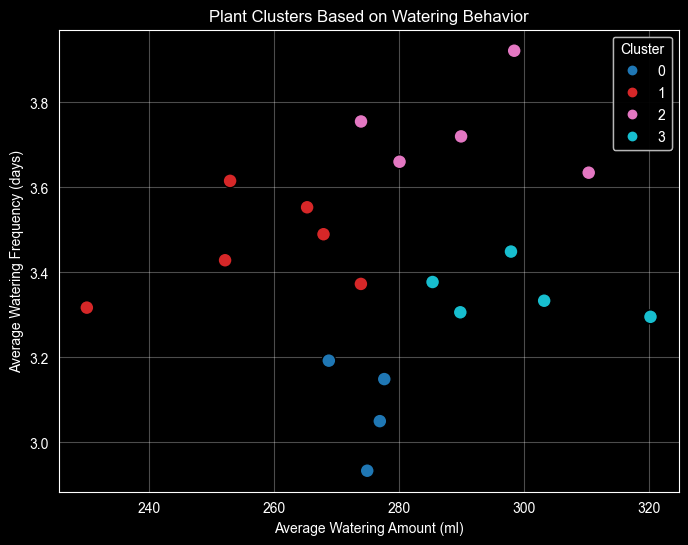

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    plant_watering_profile["Watering_Amount_ml"],
    plant_watering_profile["Watering_Frequency_days"],
    c=plant_watering_profile["Watering_Cluster"],
    cmap="tab10",
    s=100,
    edgecolors="black"
)

plt.xlabel("Average Watering Amount (ml)")
plt.ylabel("Average Watering Frequency (days)")
plt.title("Plant Clusters Based on Watering Behavior")
plt.grid(True, alpha=0.3)

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()

In [22]:
df_clustered = df.merge(
    plant_watering_profile[["Plant_ID", "Watering_Cluster"]],
    on="Plant_ID",
    how="left"
)

df_clustered[["Plant_ID", "Watering_Cluster"]].head()

,Plant_ID,Watering_Cluster
0,Sansevieria cylindrica,0
1,Aloe vera,2
2,Ficus lyrata,3
3,Monstera deliciosa,1
4,Ficus lyrata,3


In [23]:
feature_sets["with_watering_cluster"] = [
    "Plant_ID",
    "Watering_Cluster",
    "Soil_Type",
    "Room_Temperature_C",
    "Humidity_%",
    "Soil_Moisture_%",
    "Light",
    "Watering_Frequency_days",
    "Health_Score",
    "Height_cm",
    "Leaf_Count",
    "New_Growth_Count"
]

In [24]:
all_results = []

for feature_set_name, features in feature_sets.items():
    X = df_clustered[features]
    y = df_clustered["Watering_Amount_ml"]

    preprocessor = make_preprocessor(X)

    for model_name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )

        all_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "MAE": -scores["test_mae"].mean(),
            "RMSE": -scores["test_rmse"].mean(),
            "R2": scores["test_r2"].mean()
        })

cluster_results_df = pd.DataFrame(all_results)
cluster_results_df.sort_values(by="MAE")

,feature_set,model,MAE,RMSE,R2
0,sensor_only,Dummy Average,107.939242,124.723618,-0.006866
11,sensor_plus_frequency,Dummy Average,107.939242,124.723618,-0.006866
22,plant_numeric,Dummy Average,107.939242,124.723618,-0.006866
33,with_plant_id,Dummy Average,107.939242,124.723618,-0.006866
44,plant_id_frequency,Dummy Average,107.939242,124.723618,-0.006866
...,...,...,...,...,...
70,with_watering_cluster,KNN,115.819921,137.205655,-0.218334
48,plant_id_frequency,KNN,116.474698,137.299612,-0.220778
26,plant_numeric,KNN,116.510816,137.663510,-0.226618
61,plant_id_soil_frequency,Random Forest,121.488201,143.947295,-0.340854


In [25]:
cluster_results_df.sort_values(by="MAE")

,feature_set,model,MAE,RMSE,R2
0,sensor_only,Dummy Average,107.939242,124.723618,-0.006866
11,sensor_plus_frequency,Dummy Average,107.939242,124.723618,-0.006866
22,plant_numeric,Dummy Average,107.939242,124.723618,-0.006866
33,with_plant_id,Dummy Average,107.939242,124.723618,-0.006866
44,plant_id_frequency,Dummy Average,107.939242,124.723618,-0.006866
...,...,...,...,...,...
70,with_watering_cluster,KNN,115.819921,137.205655,-0.218334
48,plant_id_frequency,KNN,116.474698,137.299612,-0.220778
26,plant_numeric,KNN,116.510816,137.663510,-0.226618
61,plant_id_soil_frequency,Random Forest,121.488201,143.947295,-0.340854


In [26]:
cluster_results_df[
    cluster_results_df["feature_set"] == "with_watering_cluster"
].sort_values(by="MAE")

,feature_set,model,MAE,RMSE,R2
66,with_watering_cluster,Dummy Average,107.939242,124.723618,-0.006866
71,with_watering_cluster,SVR,108.220698,125.018131,-0.011827
69,with_watering_cluster,ElasticNet,108.701093,125.481470,-0.019090
68,with_watering_cluster,Ridge,109.568929,127.662448,-0.054740
67,with_watering_cluster,Linear Regression,109.608617,127.747978,-0.056160
72,with_watering_cluster,Random Forest,111.046962,129.319338,-0.082218
74,with_watering_cluster,Gradient Boosting,111.685875,131.275503,-0.115405
76,with_watering_cluster,XGBoost,112.692741,133.930997,-0.162419
75,with_watering_cluster,Hist Gradient Boosting,114.492649,136.370353,-0.206054
73,with_watering_cluster,Extra Trees,114.514926,133.356521,-0.150765


In [27]:
plant_input_profile = df.groupby("Plant_ID").agg({
    "Watering_Frequency_days": "mean",
    "Soil_Moisture_%": "mean",
    "Light": "mean",
    "Room_Temperature_C": "mean",
    "Humidity_%": "mean",
    "Health_Score": "mean",
    "Height_cm": "mean",
    "Leaf_Count": "mean",
    "New_Growth_Count": "mean"
}).reset_index()

plant_input_profile.head()

,Plant_ID,Watering_Frequency_days,Soil_Moisture_%,Light,Room_Temperature_C,Humidity_%,Health_Score,Height_cm,Leaf_Count,New_Growth_Count
0,Aglaonema commutatum,3.634615,32.403846,509.557692,23.905769,52.376923,3.057692,24.402308,29.942308,4.807692
1,Aloe vera,3.660377,33.420755,601.037736,23.386792,53.109434,3.188679,27.251132,26.924528,4.547170
2,Anthurium andraeanum,3.720000,32.638000,422.200000,24.138000,52.196000,2.600000,24.555200,26.440000,4.160000
3,Begonia maculata,3.489796,35.802041,514.469388,24.357143,57.626531,3.285714,27.672041,24.346939,4.877551
4,Calathea orbifolia,3.148936,38.265957,491.659574,23.923404,53.938298,2.787234,27.602128,25.446809,4.468085


## 11. Clustering by Environmental Features

I also tried clustering based on environmental and plant features, such as:

- temperature
- humidity
- light
- soil moisture
- health score
- height
- leaf count

The idea was to check whether plants naturally separate into clear groups based on their conditions.

However, the clustering scores were low, meaning the groups were not very strong.

This suggested that the data does not clearly separate into meaningful clusters based on these features.



In [28]:
from sklearn.preprocessing import StandardScaler

input_cluster_features = [
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score",
    "Height_cm",
    "Leaf_Count",
    "New_Growth_Count"
]

scaler = StandardScaler()

X_input_scaled = scaler.fit_transform(
    plant_input_profile[input_cluster_features]
)

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_input_scaled)

    score = silhouette_score(X_input_scaled, labels)

    print("k =", k, "silhouette =", score)

k = 2 silhouette = 0.10987404624780958
k = 3 silhouette = 0.10979556215583566
k = 4 silhouette = 0.0762533691897809
k = 5 silhouette = 0.09490834746879755
k = 6 silhouette = 0.08844177997490123
k = 7 silhouette = 0.08020298366690048
k = 8 silhouette = 0.040946246147996766


## 12. Trying to Predict Watering Frequency

After watering amount prediction was weak, I also tested whether watering frequency could be predicted.

The target was Watering_Frequency_days.

The idea was:

> Maybe predicting how often a plant should be watered is easier than predicting the exact water amount.

But the result was similar to before.

The machine learning model did not perform better than the dummy baseline.

This showed that watering frequency also was not strongly predictable from the available sensor-like data.



In [30]:
target = "Watering_Frequency_days"

In [31]:
feature_sets_frequency = {
    "sensor_only": [
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light"
    ],
    "with_plant_id": [
        "Plant_ID",
        "Soil_Type",
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light",
        "Health_Score",
        "Height_cm",
        "Leaf_Count",
        "New_Growth_Count"
    ]
}

In [32]:
FINAL_FEATURE_SET_NAME = "sensor_only"

final_features = feature_sets[FINAL_FEATURE_SET_NAME]

X = df[final_features]
y = df[target]

X.head()

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
0,21.7,77.5,51.9,725
1,22.6,68.9,28.2,725
2,17.2,44.3,13.6,475
3,25.0,72.2,38.4,100
4,23.2,51.6,37.9,325


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (793, 4)
Test size: (199, 4)


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

dummy_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X_train)),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_pipeline.fit(X_train, y_train)

dummy_predictions = dummy_pipeline.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = mean_squared_error(y_test, dummy_predictions) ** 0.5
dummy_r2 = r2_score(y_test, dummy_predictions)

print("Dummy Average Results")
print("MAE:", dummy_mae)
print("RMSE:", dummy_rmse)
print("R2:", dummy_r2)

Dummy Average Results
MAE: 1.5435500326348008
RMSE: 1.7454868665193164
R2: -0.01997914457334926


In [36]:
extra_trees_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X_train)),
    ("model", ExtraTreesRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "model__bootstrap": [True, False]
}

extra_search = RandomizedSearchCV(
    extra_trees_pipeline,
    param_distributions=param_grid,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

extra_search.fit(X_train, y_train)

print("Best params:")
print(extra_search.best_params_)

print("Best CV MAE:")
print(-extra_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params:
{'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 1, 'model__max_features': 0.8, 'model__max_depth': 20, 'model__bootstrap': False}
Best CV MAE:
1.528935375745622


In [37]:
final_model = extra_search.best_estimator_

model_predictions = final_model.predict(X_test)

model_mae = mean_absolute_error(y_test, model_predictions)
model_rmse = mean_squared_error(y_test, model_predictions) ** 0.5
model_r2 = r2_score(y_test, model_predictions)

print("Final Extra Trees Results")
print("MAE:", model_mae)
print("RMSE:", model_rmse)
print("R2:", model_r2)

print()
print("Comparison to Dummy Average")
print("Dummy MAE:", dummy_mae)
print("Model MAE:", model_mae)
print("MAE improvement:", dummy_mae - model_mae)

Final Extra Trees Results
MAE: 1.5906975799307737
RMSE: 1.825400125369179
R2: -0.11551206819216442

Comparison to Dummy Average
Dummy MAE: 1.5435500326348008
Model MAE: 1.5906975799307737
MAE improvement: -0.047147547295972814


In [38]:
cv_scores = cross_validate(
    final_model,
    X,
    y,
    cv=5,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

cv_mae = -cv_scores["test_mae"].mean()
cv_rmse = -cv_scores["test_rmse"].mean()
cv_r2 = cv_scores["test_r2"].mean()

print("Final model cross-validation")
print("CV MAE:", cv_mae)
print("CV RMSE:", cv_rmse)
print("CV R2:", cv_r2)

Final model cross-validation
CV MAE: 1.5474303238592284
CV RMSE: 1.7834358767466827
CV R2: -0.041688269835337174


## 13. Trying to Predict Plant Health Score

I also tested another possible target: Health_Score.

The goal was to check whether the dataset might be better for predicting plant health instead of watering needs.

Again, I tested several models and compared them against a dummy baseline.

The result was that the real models were not meaningfully better than the dummy model.

So the conclusion was:

> The dataset is also weak for predicting plant health score.



In [39]:
health_df = df.copy()

# Remove impossible values if present
health_df = health_df[health_df["Height_cm"] > 0].copy()

# Create deterministic Light value if Light does not already exist
light_midpoints = {
    "Low light corner": 100,
    "Filtered sunlight through curtain": 325,
    "Indirect light all day": 475,
    "3h direct morning sun": 725,
    "6h full sun": 912
}

if "Light" not in health_df.columns and "Sunlight_Exposure" in health_df.columns:
    health_df["Light"] = health_df["Sunlight_Exposure"].map(light_midpoints)

if "Light" in health_df.columns:
    health_df["Light"] = health_df["Light"].fillna(health_df["Light"].median())

health_df.shape

(992, 19)

<Axes: >

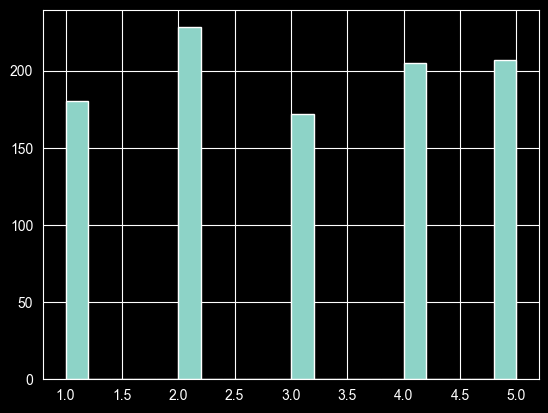

In [40]:
health_df["Health_Score"].describe()
health_df["Health_Score"].hist(bins=20)

In [41]:
target = "Health_Score"

health_feature_sets = {
    "sensor_only": [
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light"
    ],

    "watering_and_sensor": [
        "Watering_Amount_ml",
        "Watering_Frequency_days",
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light"
    ],

    "plant_numeric": [
        "Watering_Amount_ml",
        "Watering_Frequency_days",
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light",
        "Height_cm",
        "Leaf_Count",
        "New_Growth_Count"
    ],

    "with_plant_id_and_soil": [
        "Plant_ID",
        "Soil_Type",
        "Watering_Amount_ml",
        "Watering_Frequency_days",
        "Room_Temperature_C",
        "Humidity_%",
        "Soil_Moisture_%",
        "Light",
        "Height_cm",
        "Leaf_Count",
        "New_Growth_Count"
    ]
}

In [42]:
def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor

In [43]:
models = {
    "Dummy Average": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(max_iter=10000),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

health_results = []

for feature_set_name, features in health_feature_sets.items():
    X = health_df[features]
    y = health_df[target]

    preprocessor = make_preprocessor(X)

    for model_name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )

        health_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "MAE": -scores["test_mae"].mean(),
            "RMSE": -scores["test_rmse"].mean(),
            "R2": scores["test_r2"].mean()
        })

health_results_df = pd.DataFrame(health_results)

health_results_df.sort_values(by="MAE").head(20)

,feature_set,model,MAE,RMSE,R2
35,with_plant_id_and_soil,SVR,1.222445,1.446653,-0.055255
0,sensor_only,Dummy Average,1.222571,1.413194,-0.003194
13,watering_and_sensor,ElasticNet,1.222571,1.413194,-0.003194
3,sensor_only,ElasticNet,1.222571,1.413194,-0.003194
20,plant_numeric,Dummy Average,1.222571,1.413194,-0.003194
30,with_plant_id_and_soil,Dummy Average,1.222571,1.413194,-0.003194
23,plant_numeric,ElasticNet,1.222571,1.413194,-0.003194
10,watering_and_sensor,Dummy Average,1.222571,1.413194,-0.003194
33,with_plant_id_and_soil,ElasticNet,1.222571,1.413194,-0.003194
2,sensor_only,Ridge,1.229872,1.415624,-0.006785


In [44]:
health_results_df.sort_values(by="R2", ascending=False).head(20)

,feature_set,model,MAE,RMSE,R2
0,sensor_only,Dummy Average,1.222571,1.413194,-0.003194
3,sensor_only,ElasticNet,1.222571,1.413194,-0.003194
30,with_plant_id_and_soil,Dummy Average,1.222571,1.413194,-0.003194
33,with_plant_id_and_soil,ElasticNet,1.222571,1.413194,-0.003194
23,plant_numeric,ElasticNet,1.222571,1.413194,-0.003194
20,plant_numeric,Dummy Average,1.222571,1.413194,-0.003194
13,watering_and_sensor,ElasticNet,1.222571,1.413194,-0.003194
10,watering_and_sensor,Dummy Average,1.222571,1.413194,-0.003194
2,sensor_only,Ridge,1.229872,1.415624,-0.006785
1,sensor_only,Linear Regression,1.229886,1.415632,-0.006797


In [45]:
BEST_HEALTH_FEATURE_SET = "with_plant_id_and_soil"
BEST_HEALTH_MODEL_NAME = "SVR"

In [46]:
BEST_HEALTH_FEATURE_SET = "with_plant_id_and_soil"

X = health_df[health_feature_sets[BEST_HEALTH_FEATURE_SET]]
y = health_df["Health_Score"]

health_pipeline = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", ExtraTreesRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "model__bootstrap": [True, False]
}

health_search = RandomizedSearchCV(
    health_pipeline,
    param_distributions=param_grid,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

health_search.fit(X, y)

print("Best params:")
print(health_search.best_params_)

print("Best CV MAE:")
print(-health_search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params:
{'model__n_estimators': 800, 'model__min_samples_split': 5, 'model__min_samples_leaf': 12, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__bootstrap': True}
Best CV MAE:
1.2302245159981176


In [47]:
dummy_health = Pipeline([
    ("preprocessor", make_preprocessor(X)),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_scores = cross_validate(
    dummy_health,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

best_health_model = health_search.best_estimator_

best_scores = cross_validate(
    best_health_model,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

comparison = pd.DataFrame([
    {
        "model": "Dummy Average",
        "MAE": -dummy_scores["test_mae"].mean(),
        "RMSE": -dummy_scores["test_rmse"].mean(),
        "R2": dummy_scores["test_r2"].mean()
    },
    {
        "model": "Tuned Extra Trees",
        "MAE": -best_scores["test_mae"].mean(),
        "RMSE": -best_scores["test_rmse"].mean(),
        "R2": best_scores["test_r2"].mean()
    }
])

comparison

,model,MAE,RMSE,R2
0,Dummy Average,1.222571,1.413194,-0.003194
1,Tuned Extra Trees,1.230225,1.416388,-0.007854


okayyyyy i am stoping with everything will noow export the model and deploy it

## 14. Final Decision: Create a Deployable Prototype Model

Even though the model was not highly accurate, I still created a final model that could be used as a prototype.

The reason was that our project still needs a working ML pipeline.

The final model uses only sensor-style inputs:

- Room_Temperature_C
- Humidity_%
- Soil_Moisture_%
- Light

The target is Watering_Amount_ml.

This makes the model closer to how our real system should work, because these are the same types of values that can come from the IoT device.

The thinking here was:

> The model does not need to be perfect right now. The important part is proving that the backend can send data, the ML service can run a model, and the system can return a watering amount.



In [48]:
model_df = df.copy()

# Remove impossible plant heights if the column exists
if "Height_cm" in model_df.columns:
    model_df = model_df[model_df["Height_cm"] > 0].copy()

# Create deterministic Light value if Light does not already exist
light_midpoints = {
    "Low light corner": 100,
    "Filtered sunlight through curtain": 325,
    "Indirect light all day": 475,
    "3h direct morning sun": 725,
    "6h full sun": 912
}

if "Light" not in model_df.columns and "Sunlight_Exposure" in model_df.columns:
    model_df["Light"] = model_df["Sunlight_Exposure"].map(light_midpoints)

model_df["Light"] = model_df["Light"].fillna(model_df["Light"].median())

model_df.shape

(992, 19)

In [49]:
features = [
    "Room_Temperature_C",
    "Humidity_%",
    "Soil_Moisture_%",
    "Light"
]

target = "Watering_Amount_ml"

X = model_df[features]
y = model_df[target]

X.head()

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light
0,21.7,77.5,51.9,725
1,22.6,68.9,28.2,725
2,17.2,44.3,13.6,475
3,25.0,72.2,38.4,100
4,23.2,51.6,37.9,325


In [50]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), features)
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (793, 4)
Test size: (199, 4)


In [52]:
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_rmse = mean_squared_error(y_test, dummy_pred) ** 0.5
dummy_r2 = r2_score(y_test, dummy_pred)

print("Dummy Average Baseline")
print("MAE:", dummy_mae)
print("RMSE:", dummy_rmse)
print("R2:", dummy_r2)

Dummy Average Baseline
MAE: 103.61490301444168
RMSE: 121.63983157682885
R2: -0.003026861318557117


In [53]:
extra_trees_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "model__bootstrap": [True, False]
}

search = RandomizedSearchCV(
    extra_trees_pipeline,
    param_distributions=param_grid,
    n_iter=80,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:")
print(search.best_params_)

print("Best CV MAE:")
print(-search.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params:
{'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 5, 'model__bootstrap': True}
Best CV MAE:
109.56692173744707


In [54]:
best_model = search.best_estimator_

model_pred = best_model.predict(X_test)

model_mae = mean_absolute_error(y_test, model_pred)
model_rmse = mean_squared_error(y_test, model_pred) ** 0.5
model_r2 = r2_score(y_test, model_pred)

print("Sensor-only Extra Trees Model")
print("MAE:", model_mae)
print("RMSE:", model_rmse)
print("R2:", model_r2)

print()
print("Comparison to Dummy Average")
print("Dummy MAE:", dummy_mae)
print("Model MAE:", model_mae)
print("MAE improvement:", dummy_mae - model_mae)

Sensor-only Extra Trees Model
MAE: 103.32992188009374
RMSE: 122.3112723344627
R2: -0.014130656218179327

Comparison to Dummy Average
Dummy MAE: 103.61490301444168
Model MAE: 103.32992188009374
MAE improvement: 0.2849811343479445


In [55]:
cv_scores = cross_validate(
    best_model,
    X,
    y,
    cv=5,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

cv_mae = -cv_scores["test_mae"].mean()
cv_rmse = -cv_scores["test_rmse"].mean()
cv_r2 = cv_scores["test_r2"].mean()

print("Cross-validation results")
print("CV MAE:", cv_mae)
print("CV RMSE:", cv_rmse)
print("CV R2:", cv_r2)

Cross-validation results
CV MAE: 108.75453956241722
CV RMSE: 125.84536978068736
CV R2: -0.025553336830142114


In [56]:
best_params = {
    key.replace("model__", ""): value
    for key, value in search.best_params_.items()
}

final_sensor_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        random_state=42,
        **best_params
    ))
])

final_sensor_model.fit(X, y)

print("Final sensor-only model trained on full dataset.")

Final sensor-only model trained on full dataset.


## 15. Exporting the Model

After training the final model, I exported it using joblib.

This created a file called watering_amount_sensor_model.joblib.

I also saved metadata about the model.

The metadata included information such as:

- model name
- target column
- input features
- test results
- cross-validation results
- Azure input mapping

This was useful because the model file alone is not enough. We also need to know what inputs the model expects and how good the model was during testing.

The thinking here was:

> If someone uses this model later, they should know exactly what features it expects and how it was evaluated.



In [57]:
import joblib
import json

model_filename = "watering_amount_sensor_model.joblib"
metadata_filename = "watering_amount_sensor_model_metadata.json"

joblib.dump(final_sensor_model, model_filename)

metadata = {
    "model_name": "ExtraTreesRegressor",
    "target": target,
    "feature_set": "sensor_only",
    "features": features,
    "input_mapping_for_azure": {
        "temperature": "Room_Temperature_C",
        "humidity": "Humidity_%",
        "soil_moisture": "Soil_Moisture_%",
        "light": "Light"
    },
    "test_results": {
        "dummy_mae": float(dummy_mae),
        "dummy_rmse": float(dummy_rmse),
        "dummy_r2": float(dummy_r2),
        "model_mae": float(model_mae),
        "model_rmse": float(model_rmse),
        "model_r2": float(model_r2),
        "mae_improvement_over_dummy": float(dummy_mae - model_mae)
    },
    "cross_validation_results": {
        "cv_mae": float(cv_mae),
        "cv_rmse": float(cv_rmse),
        "cv_r2": float(cv_r2)
    },
    "note": "Sensor-only model exported to match the backend-to-ML interface. Performance is close to the dummy average baseline because the mocked dataset has weak predictive signal."
}

with open(metadata_filename, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved model:", model_filename)
print("Saved metadata:", metadata_filename)

Saved model: watering_amount_sensor_model.joblib
Saved metadata: watering_amount_sensor_model_metadata.json


In [58]:
loaded_model = joblib.load("watering_amount_sensor_model.joblib")

sample_input = pd.DataFrame([{
    "Room_Temperature_C": 22.5,
    "Humidity_%": 65.0,
    "Soil_Moisture_%": 40.0,
    "Light": 800
}])

prediction = loaded_model.predict(sample_input)[0]

print("Raw prediction:", prediction)
print("Rounded prediction:", round(prediction), "ml")

Raw prediction: 278.73894164163625
Rounded prediction: 279 ml


## 16. Testing the Exported Model

After exporting the model, I loaded it again and tested it with sample input.

This was important because I wanted to confirm that the saved model actually works after being loaded from the file.

I also created a function that simulates how the Azure Function could receive JSON input.

Example input:

{
  "temperature": 225,
  "humidity": 650,
  "light": 800,
  "soil_moisture": 400
}

The function converts the values into the format expected by the model.

For example:

- temperature: 225 becomes 22.5
- humidity: 650 becomes 65.0

Then the model returns a predicted watering amount.

Example output:

{
  "watering_amount": 272
}

This matches the planned idea of the backend sending sensor data to the ML service and receiving a watering prediction.



In [59]:
def predict_watering_from_azure_input(request_json):
    input_df = pd.DataFrame([{
        "Room_Temperature_C": request_json["temperature"] / 10,
        "Humidity_%": request_json["humidity"] / 10,
        "Soil_Moisture_%": request_json["soil_moisture"],
        "Light": request_json["light"]
    }])

    prediction = loaded_model.predict(input_df)[0]

    prediction = round(prediction)
    prediction = max(0, min(500, prediction))

    return {
        "watering_amount": prediction
    }

In [60]:
test_request = {
    "temperature": 225,
    "humidity": 650,
    "light": 800,
    "soil_moisture": 400
}

result = predict_watering_from_azure_input(test_request)

result

{'watering_amount': 272}

## 18. Main Findings

The main finding from this notebook is that the current dataset is not strong enough for accurate watering amount prediction.

I tested:

- different feature sets
- many regression models
- hyperparameter tuning
- classification
- clustering
- watering frequency prediction
- health score prediction

But in most cases, the models were not meaningfully better than simple dummy baseline models.

This means that the current dataset is useful for experimentation and testing the pipeline, but it is probably not good enough for a final production model.



## 19. Final Conclusion

The final conclusion is:

> The notebook successfully proves the machine learning workflow, but the dataset does not provide strong enough patterns for accurate prediction.

The most useful result is not the accuracy of the model, but the fact that I now have a working prototype pipeline:

1. load and clean data
2. prepare features
3. train models
4. compare against baselines
5. tune models
6. export a final model
7. test the model with JSON-style input
8. prepare it for Azure Function integration

This means the model can later be replaced with a better one when we have real sensor data from our system.

The current model should therefore be seen as a prototype, not a final accurate prediction model.



## 20. What I Found Out

From this work, I found out that:

- sensor-like values alone are not enough in this dataset to accurately predict watering amount
- adding more plant information did not improve the model enough
- tuning the models did not solve the problem
- classification into low, medium, and high watering was also weak
- clustering was useful for understanding plant groups, but not for improving prediction
- the final model can still be exported and used as a prototype
- real sensor data will probably be needed to create a better final model

Overall, this notebook helped me understand both the technical ML workflow and the limitations of the dataset.